# 7. Fat tails, jumps and simulated paths

**What this notebook answers:** real returns are not bell-shaped, and volatility is not constant.
When those things are true there is no closed-form touch probability, so we simulate. How much does
it change the answer, and which simulation should we trust?

> **Data note.** Uses the local Kraken bar cache and the backtest results; outputs are saved in the notebook.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np, pandas as pd, polars as pl, matplotlib.pyplot as plt
from scipy import stats
import _style as st
from pmq.crypto import ticks, grid, features, barrier, paths, backtest

st.setup()
DAY = 1 / 365
rng = np.random.default_rng(3)
bars = ticks.load_bars("../data/bars/XBT_1m.parquet")
g = grid.build_hourly_grid(bars, start="2017-01-01")
r = features.hourly_log_returns(g)
r_recent = r[-24 * 365 * 4:]                      # roughly 2022-2025

## 7.1 How fat are the tails?

If hourly returns were bell-shaped, a move of 5 standard deviations would essentially never happen (once in
several thousand years of hours). Bitcoin has them regularly. The histogram below (log scale, so the tails are visible) compares the real standardised returns with the bell curve:

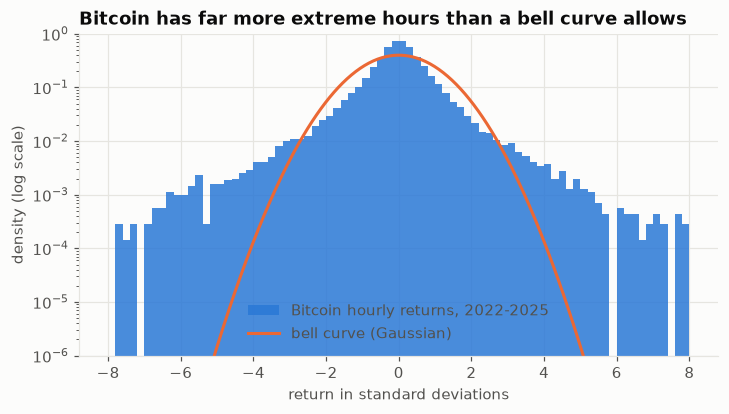

excess kurtosis: 13.9 (0 for a bell curve)
hours beyond 4 std: 309 | bell curve would give: 2.2


In [2]:
z = (r_recent - r_recent.mean()) / r_recent.std()
fig, ax = plt.subplots()
bins = np.linspace(-8, 8, 81)
ax.hist(z, bins=bins, density=True, color=st.BLUE, alpha=0.85, label="Bitcoin hourly returns, 2022-2025")
xs = np.linspace(-8, 8, 400)
ax.plot(xs, stats.norm.pdf(xs), color=st.ORANGE, lw=2, label="bell curve (Gaussian)")
ax.set_yscale("log"); ax.set_ylim(1e-6, 1); ax.set_xlabel("return in standard deviations"); ax.set_ylabel("density (log scale)")
ax.set_title("Bitcoin has far more extreme hours than a bell curve allows"); ax.legend()
plt.show()
print("excess kurtosis:", round(stats.kurtosis(r_recent), 1), "(0 for a bell curve)")
print("hours beyond 4 std:", int((np.abs(z) > 4).sum()), "| bell curve would give:", round(2 * stats.norm.sf(4) * z.size, 1))

Two things make returns fat-tailed and they need different tools:

* **Volatility changes** (calm then storm): pooled together, a mix of small and large bell curves is fat-tailed. Tool: a volatility model plus *filtered historical simulation*.
* **Jumps**: sudden moves far bigger than diffusion allows. Tool: a *jump-diffusion* model.

## 7.2 Jump-diffusion (Merton)

Merton's model adds random jumps to the smooth random walk: at random times (a Poisson process with rate $\lambda$ per year)
the log-price jumps by a normal amount with mean $m$ and spread $s_J$. We fit it by splitting returns using a *robust* scale (the median absolute deviation, which jumps cannot inflate): returns beyond 4.5 robust standard deviations are called jumps, the rest give the diffusion volatility.

In [3]:
dt = 1 / 8760
rows = []
for year in (2022, 2023, 2024, 2025):
    ry = r[(g.t0 + np.arange(len(g)) * np.timedelta64(1, "h")).astype("datetime64[Y]").astype(int) + 1970 == year]
    p = paths.fit_merton(ry, dt)
    rows.append({"year": year, "diffusion vol %": p.sigma * 100, "jumps per year": p.jump_rate, "jump size std %": p.jump_std * 100,
                 "share of variance from jumps %": 100 * p.jump_rate * (p.jump_mean**2 + p.jump_std**2) / p.total_variance_rate})
merton_by_year = pd.DataFrame(rows).set_index("year"); merton_by_year.round(1)

,diffusion vol %,jumps per year,jump size std %,share of variance from jumps %
year,,,,
2022,46.5,278.0,2.7,48.7
2023,28.9,265.0,2.0,54.7
2024,41.2,215.4,2.3,39.5
2025,34.4,202.0,2.0,41.3


**How to read it.** A fitted "jump" here is an hourly move beyond about 3 diffusion standard deviations, and the model finds 200-280 of them a year (roughly one every 1-2 days) with a size of 2-3%. So on hourly data the "jumps" are really the **fat-tailed everyday shocks** that fill out the tails of Bitcoin's hourly distribution, not rare once-a-year crashes; they account for 40-55% of the variance. That is a useful description, but it is a fit to the data, not a discovery about events.

## 7.3 Filtered historical simulation (FHS)

Instead of assuming a shape, **reuse the real shocks**:

1. Estimate the volatility at each past hour with a volatility model (EWMA or GARCH).
2. Divide each return by that hour's volatility to get a *standardised shock*. Those shocks look identically distributed but keep the real fat tails.
3. Simulate the future by drawing shocks (in blocks, to keep any short-range dependence) and multiplying by a **simulated** volatility that reacts to the simulated returns.

The result keeps fat tails **and** volatility clustering without assuming a distribution.

## 7.4 Do the models disagree? A 7-day ladder for Bitcoin on the last day of the data

Careful: models differ in **two** ways. Some know the *current* volatility (Bitcoin had been calm), others use the 3-year average. To separate the effects we include constant-volatility (GBM) references at *both* levels.

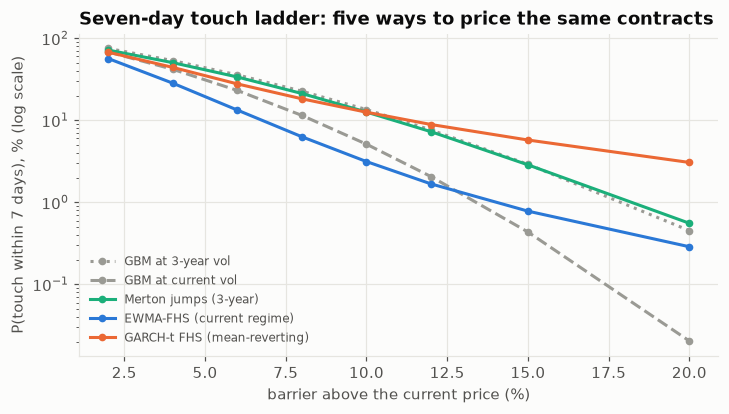

BTC $87,500; 3-year volatility 47%, current EWMA volatility 36%


,GBM at 3-year vol,GBM at current vol,Merton jumps (3-year),EWMA-FHS (current regime),GARCH-t FHS (mean-reverting)
+2%,75.26,68.16,71.89,56.69,67.75
+4%,53.48,41.88,50.45,28.37,44.18
+6%,35.84,23.12,33.75,13.33,27.79
+8%,22.66,11.47,21.22,6.30,18.29
+10%,13.52,5.11,12.60,3.14,12.55
+12%,7.62,2.06,7.26,1.68,8.88
+15%,2.91,0.43,2.86,0.78,5.75
+20%,0.45,0.02,0.56,0.29,3.06


In [4]:
h_hours, T = 24 * 7, 7 * DAY
hist = r[-24 * 365 * 3:]                                      # three years of hourly returns for FHS
s0 = g.close[-1]
sigma_now = float(features.build_features(g).ewma_vol[-1])
sigma_total = float(np.sqrt(np.mean(hist**2) * 8760))
mp = paths.fit_merton(hist, dt)
inc_m = paths.merton_increments(60_000, 168, T, mp, 0.0, rng)
inc_e = paths.ewma_fhs_increments(hist, 60_000, 168, rng, lam=0.985)
inc_g = paths.garch_fhs_increments(hist[-4000:], 6000, 168, seed=1)
levels = np.array([2, 4, 6, 8, 10, 12, 15, 20]) / 100
res = {"GBM at 3-year vol": [], "GBM at current vol": [], "Merton jumps (3-year)": [], "EWMA-FHS (current regime)": [], "GARCH-t FHS (mean-reverting)": []}
for x in levels:
    b = np.log(1 + x)
    res["GBM at 3-year vol"].append(float(barrier.touch_probability(s0, s0 * (1 + x), sigma_total, T)))
    res["GBM at current vol"].append(float(barrier.touch_probability(s0, s0 * (1 + x), sigma_now, T)))
    res["Merton jumps (3-year)"].append(paths.mc_touch_probability(inc_m, b)[0])
    res["EWMA-FHS (current regime)"].append(paths.mc_touch_probability(inc_e, b)[0])
    res["GARCH-t FHS (mean-reverting)"].append(paths.mc_touch_probability(inc_g, b)[0])
fig, ax = plt.subplots()
styles = [(st.GREY, ":"), (st.GREY, "--"), (st.AQUA, "-"), (st.BLUE, "-"), (st.ORANGE, "-")]
for (name, vals), (colour, ls) in zip(res.items(), styles):
    ax.plot(levels * 100, np.array(vals) * 100, ls, color=colour, marker="o", ms=4, label=name)
ax.set_yscale("log"); ax.set_xlabel("barrier above the current price (%)"); ax.set_ylabel("P(touch within 7 days), % (log scale)")
ax.set_title("Seven-day touch ladder: five ways to price the same contracts"); ax.legend(loc="lower left", fontsize=8)
plt.show()
print(f"BTC ${s0:,.0f}; 3-year volatility {sigma_total*100:.0f}%, current EWMA volatility {sigma_now*100:.0f}%")
pd.DataFrame(res, index=[f"+{int(x*100)}%" for x in levels]).mul(100).round(2)

Read it in two steps:

* **Regime.** Volatility had just fallen, so the two models that *know the current regime* (EWMA-FHS, and the GBM at current volatility) sit far below the 3-year-average models everywhere. Which regime to trust is a forecasting question (notebook 5).
* **Tail shape at the same volatility.** Compare EWMA-FHS with GBM at current vol: the fat-tailed simulation gives a *higher* probability for far barriers and a lower one for near barriers. GARCH-t is the most generous in the tail because it lets volatility revert upward from today's calm level.

Which is right? Judge on events that already happened.

## 7.5 The reality check: hit rates in the backtest

The backtest (notebook 8) lists 7-day contracts for every strike distance $z$ (in units of the trailing 30-day volatility) and records whether each was hit.
Compare **what actually happened** with what a constant-volatility formula predicted:

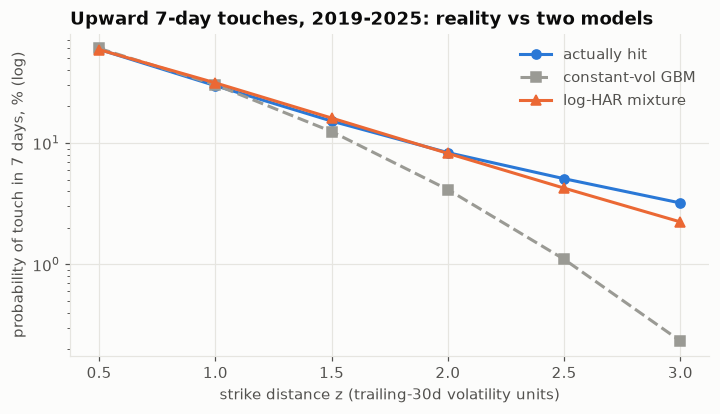

,actually hit,constant-vol GBM,log-HAR mixture,contracts
z,,,,
0.5,58.90,60.02,58.62,10108
1.0,29.61,30.16,31.22,10108
1.5,15.14,12.41,16.03,10108
2.0,8.32,4.13,8.20,10108
2.5,5.08,1.10,4.25,10108
3.0,3.21,0.23,2.24,10108


In [5]:
df = pl.read_parquet("../outputs/backtest_XBT.parquet").filter((pl.col("horizon_d") == 7) & (pl.col("direction") == 1.0))
tab = (df.group_by("z").agg(pl.col("label").mean().alias("actually hit"), pl.col("gbm_trailing30").mean().alias("constant-vol GBM"),
                            pl.col("har_mix").mean().alias("log-HAR mixture"), pl.len().alias("contracts")).sort("z").to_pandas().set_index("z"))
fig, ax = plt.subplots()
ax.plot(tab.index, tab["actually hit"] * 100, "o-", color=st.BLUE, label="actually hit")
ax.plot(tab.index, tab["constant-vol GBM"] * 100, "s--", color=st.GREY, label="constant-vol GBM")
ax.plot(tab.index, tab["log-HAR mixture"] * 100, "^-", color=st.ORANGE, label="log-HAR mixture")
ax.set_yscale("log"); ax.set_xlabel("strike distance z (trailing-30d volatility units)"); ax.set_ylabel("probability of touch in 7 days, % (log)")
ax.set_title("Upward 7-day touches, 2019-2025: reality vs two models"); ax.legend()
plt.show()
(tab * [100, 100, 100, 1]).round(2)

(Contracts are strikes above the price; 10,108 contracts per row, 2019-2025.) The verdict is clear: the **constant-volatility formula badly under-predicts far hits**: at z = 2 it says 4.1% while 8.3% were hit, and at z = 3 it says 0.23% while 3.2% were hit, more than **ten times** too low. The log-HAR mixture is much closer (8.2% and 2.2%) but still a little low at z = 3. Fat tails and volatility uncertainty are not academic detail; they are the difference between a fair price and a very cheap long shot.

## 7.6 Why the bridge matters when simulating

We simulate the price only at hourly points but the venue watches every minute. A path can cross the barrier *between* two simulated points and come back. The **Brownian bridge** says, given both end points below the barrier at $b$, the chance of a crossing in between is exactly

$$q = \exp\!\left(-\frac{2\,(b - x_i)(b - x_{i+1})}{v}\right),$$

where $v$ is the step's variance. Adding these chances step by step (instead of only checking the simulated points) removes the bias with **very few** steps:

In [6]:
sigma = 0.8
exact = float(barrier.touch_probability(100.0, 110.0, sigma, 7 * DAY))
rows = []
for n_steps in (3, 6, 12, 24, 84):
    inc = paths.gbm_increments(200_000, n_steps, 7 * DAY, sigma, 0.0, rng)
    with_bridge, se = paths.mc_touch_probability(inc, np.log(1.10))
    naive = float(np.mean(np.cumsum(inc.dx, axis=1).max(axis=1) >= np.log(1.10)))
    rows.append({"simulation steps in a week": n_steps, "endpoints only": naive, "with bridge": with_bridge, "exact formula": exact})
pd.DataFrame(rows).set_index("simulation steps in a week").round(4)

,endpoints only,with bridge,exact formula
simulation steps in a week,,,
3,0.2357,0.3711,0.3712
6,0.2650,0.3705,0.3712
12,0.2916,0.3722,0.3712
24,0.3138,0.3724,0.3712
84,0.3384,0.3716,0.3712


Checking only the simulated points understates the probability badly when steps are few; the bridge version is on target even with three steps a week. This is both a **bias fix** and a **speed-up**: fewer steps for the same accuracy.

## Recap

* Bitcoin's hourly returns have very fat tails (excess kurtosis about 14; 309 hours beyond 4 standard deviations where a bell curve allows about 2); two causes need two tools: **volatility clustering** and **jumps**.
* **Merton** jump-diffusion and **filtered historical simulation** (EWMA or GARCH-t) give tail probabilities that a constant-volatility bell curve cannot.
* The **Brownian bridge** removes discretisation bias and lets us simulate with few steps.
* The honest test is the backtest hit rate by strike distance (7.5), not the model's own assumptions.